# Laboratorio 1 — Task 3

## Inciso (a) - El modelo

La comunidad tiene población total constante $N$ y cada persona pertenece a exactamente uno de tres stocks: no adoptantes $S$, adoptantes activos $A$ y ex adoptantes $R$. El sistema derivado en el Task 1 es:

$$
\begin{aligned}
\frac{dS}{dt} &= -\beta S - \gamma \frac{S A}{N} \\[4pt]
\frac{dA}{dt} &= \beta S + \gamma \frac{S A}{N} + \varepsilon \frac{R A}{N} - \delta A \\[4pt]
\frac{dR}{dt} &= \delta A - \varepsilon \frac{R A}{N}
\end{aligned}
$$

Los cuatro flujos son la adopción institucional $\beta S$, la adopción por imitación $\frac {\gamma S A}{N}$, el abandono $\delta A$ y la reactivación $\frac{\varepsilon R A}{N}$.

### Parámetros y condiciones iniciales del Task 3

| Símbolo | Significado | Valor | Unidades |
|---|---|---|---|
| $N$ | población total | 10 000 | personas |
| $\beta$ | tasa fraccional de campaña institucional | 0.02 | 1/semana |
| $\gamma$ | coeficiente de imitación (contacto $S$–$A$) | 0.30 | 1/semana |
| $\delta$ | tasa fraccional de abandono | 0.05 | 1/semana |
| $\varepsilon$ | coeficiente de reactivación (contacto $R$–$A$) | 0.10 | 1/semana |
| $S_0,\ A_0,\ R_0$ | condiciones iniciales | 9 800, 200, 0 | personas |
| $T$ | horizonte de simulación | 100 | semanas |

> **Nota**: En el Task 1 se listaron las unidades de los flujos en personas/mes, pero en este Task se fija $\Delta t$ y $T$ en semanas. Este notebook adopta la semana como unidad temporal y por tanto interpreta los coeficientes en 1/semana. La estructura del modelo no cambia; solo se fija una unidad consistente.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del modelo (unidad temporal: semanas).
P = {
    "N": 10_000.0,
    "beta": 0.02,
    "gamma": 0.30,
    "delta": 0.05,
    "epsilon": 0.10,
}

# Estado inicial en el orden [S, A, R].
Y0 = np.array([9_800.0, 200.0, 0.0])
T_FINAL = 100.0

# Equilibrio endémico derivado en el Task 2, usado como referencia analítica.
A_EQ = P["N"] * (1.0 - P["delta"] / P["epsilon"])
R_EQ = P["N"] * P["delta"] / P["epsilon"]

print(f"Población inicial total : {Y0.sum():,.1f} personas (N = {P['N']:,.1f})")
print(f"Equilibrio del Task 2   : S* = 0.0, A* = {A_EQ:,.1f}, R* = {R_EQ:,.1f}")

Población inicial total : 10,000.0 personas (N = 10,000.0)
Equilibrio del Task 2   : S* = 0.0, A* = 5,000.0, R* = 5,000.0


#### El campo vectorial como función pura

El sistema se aísla en una sola función que recibe el estado y devuelve su derivada. Esa decisión tiene tres consecuencias prácticas:

- **Reuso:** Euler y RK4 reciben exactamente el mismo `f`, de modo que cualquier diferencia entre corridas proviene del integrador y no del modelo.
- **Verificabilidad:** al no guardar estado interno, la función se puede evaluar en un punto arbitrario y comprobar propiedades algebraicas (como que sus tres componentes sumen cero) sin correr una simulación completa.
- **Legibilidad:** los cuatro flujos se nombran explícitamente antes de ensamblarse, así que el código se lee como las ecuaciones del Task 1.

In [2]:
def derivadas(y, p):
    """Campo vectorial del modelo S-A-R.

    Parámetros
    ----------
    y : np.ndarray de forma (3,)
        Estado actual [S, A, R], en personas.
    p : dict
        Parámetros del modelo: N, beta, gamma, delta, epsilon.

    Retorna
    -------
    np.ndarray de forma (3,)
        Derivada [dS/dt, dA/dt, dR/dt], en personas/semana.
    """
    S, A, R = y
    N = p["N"]

    # Los cuatro flujos del Task 1, todos en personas/semana.
    adopcion_campana = p["beta"] * S
    adopcion_imitacion = p["gamma"] * S * A / N
    abandono = p["delta"] * A
    reactivacion = p["epsilon"] * R * A / N

    return np.array([
        -adopcion_campana - adopcion_imitacion,
        adopcion_campana + adopcion_imitacion + reactivacion - abandono,
        abandono - reactivacion,
    ])

In [3]:
# Validación ligera: la invariante de población vive en el campo vectorial.
# Si las tres componentes suman cero en cualquier estado, entonces d(S+A+R)/dt = 0.
for estado in (Y0, np.array([3_000.0, 5_000.0, 2_000.0]), np.array([0.0, 6_000.0, 4_000.0])):
    suma = derivadas(estado, P).sum()
    assert abs(suma) < 1e-9, f"El campo vectorial no conserva la población en {estado}"
    print(f"estado {estado} -> suma de derivadas = {suma:+.3e} personas/semana")

print("\nLa invariante es una propiedad estructural del modelo, no del integrador.")

estado [9800.  200.    0.] -> suma de derivadas = +0.000e+00 personas/semana
estado [3000. 5000. 2000.] -> suma de derivadas = +0.000e+00 personas/semana
estado [   0. 6000. 4000.] -> suma de derivadas = +0.000e+00 personas/semana

La invariante es una propiedad estructural del modelo, no del integrador.


#### Los dos integradores

Ambos métodos comparten la firma `(f, y0, dt, T, p) -> (t, Y)`, donde `Y` tiene forma `(n+1, 3)`: una fila por instante guardado y una columna por stock.

La diferencia de fondo entre los dos esquemas es cuántas veces consultan el campo vectorial por paso:

- **Euler explícito** avanza con una sola evaluación por paso, $y_{k+1} = y_k + \Delta t\, f(y_k)$.
- **RK4** promedia cuatro evaluaciones por paso, dos de ellas en el punto medio, y alcanza **orden 4**.

In [4]:
def integrar_euler(f, y0, dt, T, p):
    """Integra y' = f(y) con Euler explícito y paso fijo dt."""
    n = int(round(T / dt))
    t = np.linspace(0.0, n * dt, n + 1)
    Y = np.empty((n + 1, y0.size))
    Y[0] = y0

    for k in range(n):
        Y[k + 1] = Y[k] + dt * f(Y[k], p)

    return t, Y

In [5]:
def integrar_rk4(f, y0, dt, T, p):
    """Integra y' = f(y) con Runge-Kutta de cuarto orden y paso fijo dt."""
    n = int(round(T / dt))
    t = np.linspace(0.0, n * dt, n + 1)
    Y = np.empty((n + 1, y0.size))
    Y[0] = y0

    for k in range(n):
        y = Y[k]
        k1 = f(y, p)
        k2 = f(y + 0.5 * dt * k1, p)
        k3 = f(y + 0.5 * dt * k2, p)
        k4 = f(y + dt * k3, p)
        Y[k + 1] = y + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    return t, Y


# Evaluaciones del campo vectorial que cuesta cada paso. Es la métrica de costo
# honesta para comparar métodos: contar pasos favorece artificialmente a RK4.
EVALS_POR_PASO = {"Euler": 1, "RK4": 4}

---

## Inciso (b) — Euler

Se pide correr la simulación con Euler para $\Delta t \in \{1.0,\ 0.5,\ 0.1\}$ semanas y reportar la trayectoria de $A_t$ junto con el valor final $A_T$.

In [6]:
PASOS_EULER = [1.0, 0.5, 0.1]

corridas_euler = {
    dt: integrar_euler(derivadas, Y0, dt, T_FINAL, P) for dt in PASOS_EULER
}

for dt, (t, Y) in corridas_euler.items():
    print(f"Euler dt = {dt:>4.1f} semanas -> {len(t) - 1:>5d} pasos, "
          f"{Y.shape[0]:>5d} estados guardados, t_final = {t[-1]:.1f}")

Euler dt =  1.0 semanas ->   100 pasos,   101 estados guardados, t_final = 100.0
Euler dt =  0.5 semanas ->   200 pasos,   201 estados guardados, t_final = 100.0
Euler dt =  0.1 semanas ->  1000 pasos,  1001 estados guardados, t_final = 100.0


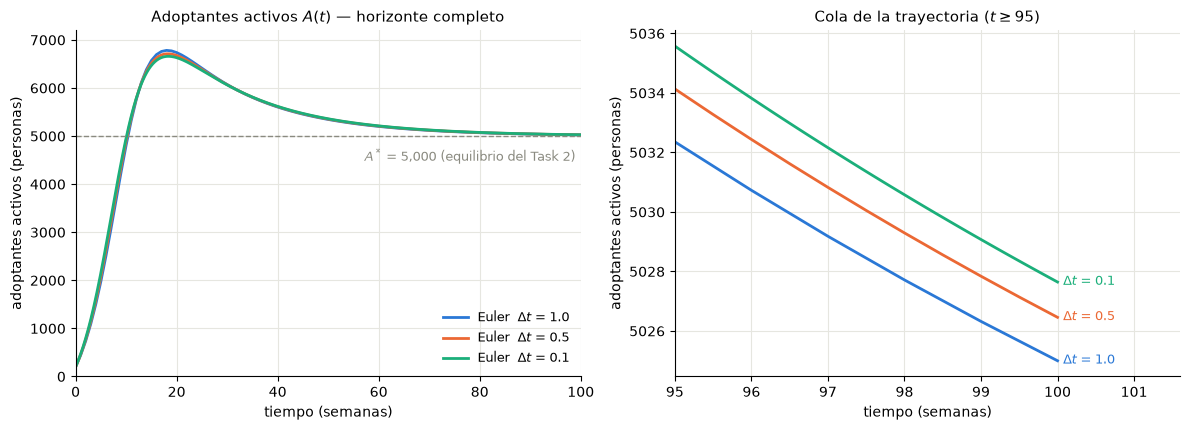

In [7]:
# Paleta categórica fija: cada dt conserva su color en todas las figuras.
COLOR_DT = {1.0: "#2a78d6", 0.5: "#eb6834", 0.1: "#1baf7a"}
COLOR_RK4 = "#4a3aa7"
GRIS = "#8a8a80"

T_ZOOM = 95.0  # ventana de la cola donde las tres curvas se separan a la vista

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(12, 4.4))

for dt, (t, Y) in corridas_euler.items():
    etiqueta = f"Euler  $\\Delta t$ = {dt}"
    ax_full.plot(t, Y[:, 1], color=COLOR_DT[dt], linewidth=2, label=etiqueta)

    cola = t >= T_ZOOM
    ax_zoom.plot(t[cola], Y[cola, 1], color=COLOR_DT[dt], linewidth=2)
    # Etiqueta directa en la punta: la identidad no depende solo del color.
    ax_zoom.annotate(f"$\\Delta t$ = {dt}", xy=(t[-1], Y[-1, 1]),
                     xytext=(4, 0), textcoords="offset points",
                     color=COLOR_DT[dt], fontsize=9, va="center")

ax_full.axhline(A_EQ, color=GRIS, linewidth=1, linestyle="--")
ax_full.annotate(f"$A^*$ = {A_EQ:,.0f} (equilibrio del Task 2)", xy=(99, A_EQ),
                 xytext=(99, A_EQ - 520), color=GRIS, fontsize=9, ha="right")
ax_full.set_title("Adoptantes activos $A(t)$ — horizonte completo", fontsize=11)
ax_full.set_xlim(0, T_FINAL)
ax_full.set_ylim(0, 7_200)
ax_full.legend(frameon=False, fontsize=9, loc="lower right")

ax_zoom.set_title(f"Cola de la trayectoria ($t \\geq {T_ZOOM:.0f}$)",
                  fontsize=11)
ax_zoom.set_xlim(T_ZOOM, T_FINAL + 1.6)

for ax in (ax_full, ax_zoom):
    ax.set_xlabel("tiempo (semanas)")
    ax.set_ylabel("adoptantes activos (personas)")
    ax.grid(True, color="#e6e6e0", linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)

fig.tight_layout()
plt.show()

In [8]:
print("Inciso (b) — estado final de cada corrida de Euler (T = 100 semanas)\n")
print(f"{'dt':>5} | {'pasos':>6} | {'S(T)':>12} | {'A(T)':>14} | {'R(T)':>14}")
print("-" * 62)
for dt, (t, Y) in corridas_euler.items():
    S, A, R = Y[-1]
    print(f"{dt:>5.1f} | {len(t) - 1:>6d} | {S:>12.6f} | {A:>14.6f} | {R:>14.6f}")

Inciso (b) — estado final de cada corrida de Euler (T = 100 semanas)

   dt |  pasos |         S(T) |           A(T) |           R(T)
--------------------------------------------------------------
  1.0 |    100 |     0.000041 |    5024.999027 |    4975.000932
  0.5 |    200 |     0.000104 |    5026.458615 |    4973.541281
  0.1 |   1000 |     0.000199 |    5027.645269 |    4972.354533


### **Reporte**

La trayectoria de $A_t$ tiene la misma forma en las tres corridas. La campaña institucional y la imitación vacían rápidamente el stock de no adoptantes, $A$ llega hasta un pico cercano a **6 650 personas** alrededor de la semana **18**, y después el abandono la arrastra hacia abajo. Una vez que $S$ se agota, la dinámica queda gobernada por el balance entre abandono y reactivación, y $A$ desciende lentamente hacia el equilibrio analítico $A^\ast = 5\,000$. A las 100 semanas todavía no lo ha alcanzado.

En el panel completo las tres curvas son visualmente indistinguibles. Esto nos dice que la discrepancia entre pasos de tiempo es de unas pocas personas sobre una escala de miles. El panel derecho amplía la cola para hacerla visible.

La tabla muestra el patrón que importa: $A_T$ **crece de forma casi constante al refinar el paso** (5 025.0 → 5 026.5 → 5 027.6). Euler subestima sistemáticamente el valor final en este problema, y la magnitud del sesgo se reduce al reducir $\Delta t$.

---

## Inciso (c) — RK4

Se pide correr RK4 con $\Delta t = 1.0$ semana, comparar su $A_T$ con las tres corridas de Euler e identificar con cuál coincide más, para concluir sobre la eficiencia relativa de ambos métodos.

Comparar corridas entre sí responde *cuál se parece a cuál*, pero no *cuál está bien*. Para eso se agrega una **solución de referencia**: RK4 con $\Delta t = 0.01$, un paso cien veces más fino. Refinar más allá de ese valor no altera los dígitos que se reportan, así que sirve como sustituto de la solución exacta y permite medir el error absoluto real de cada corrida.

In [9]:
# Corrida pedida por el enunciado.
t_rk4, Y_rk4 = integrar_rk4(derivadas, Y0, 1.0, T_FINAL, P)
A_rk4 = Y_rk4[-1, 1]

# Solución de referencia: RK4 con un paso 100 veces más fino.
DT_REF = 0.01
_, Y_ref = integrar_rk4(derivadas, Y0, DT_REF, T_FINAL, P)
A_ref = Y_ref[-1, 1]

print(f"RK4  dt = 1.00  -> A(T) = {A_rk4:.6f} personas")
print(f"RK4  dt = {DT_REF:.2f}  -> A(T) = {A_ref:.6f} personas  (solución de referencia)")

RK4  dt = 1.00  -> A(T) = 5027.944720 personas
RK4  dt = 0.01  -> A(T) = 5027.944582 personas  (solución de referencia)


In [10]:
print("Inciso (c) — comparación contra RK4 (dt = 1.0) y contra la referencia\n")
cab = (f"{'método':>7} | {'dt':>5} | {'evals de f':>10} | {'A(T)':>13} | "
       f"{'|A - A_RK4|':>12} | {'error vs ref':>13}")
print(cab)
print("-" * len(cab))

filas = [("Euler", dt, corridas_euler[dt][1][-1, 1]) for dt in PASOS_EULER]
filas.append(("RK4", 1.0, A_rk4))

for metodo, dt, A_fin in filas:
    evals = int(round(T_FINAL / dt)) * EVALS_POR_PASO[metodo]
    print(f"{metodo:>7} | {dt:>5.1f} | {evals:>10d} | {A_fin:>13.6f} | "
          f"{abs(A_fin - A_rk4):>12.6f} | {A_fin - A_ref:>+13.6f}")

mas_cercana = min(PASOS_EULER, key=lambda dt: abs(corridas_euler[dt][1][-1, 1] - A_rk4))
print(f"\nLa corrida de Euler más cercana a RK4 es dt = {mas_cercana} semanas.")

Inciso (c) — comparación contra RK4 (dt = 1.0) y contra la referencia

 método |    dt | evals de f |          A(T) |  |A - A_RK4| |  error vs ref
---------------------------------------------------------------------------
  Euler |   1.0 |        100 |   5024.999027 |     2.945693 |     -2.945555
  Euler |   0.5 |        200 |   5026.458615 |     1.486105 |     -1.485967
  Euler |   0.1 |       1000 |   5027.645269 |     0.299452 |     -0.299314
    RK4 |   1.0 |        400 |   5027.944720 |     0.000000 |     +0.000138

La corrida de Euler más cercana a RK4 es dt = 0.1 semanas.


In [11]:
# Orden de convergencia observado de Euler: al reducir dt por un factor r,
# el error debe reducirse por r^1 si el método es de primer orden.
errores = {dt: corridas_euler[dt][1][-1, 1] - A_ref for dt in PASOS_EULER}

print("Orden de convergencia observado (Euler)\n")
print(f"{'dt':>5} | {'error vs ref':>13} | {'razón esperada':>14} | {'razón obtenida':>14}")
print("-" * 58)
print(f"{1.0:>5.1f} | {errores[1.0]:>+13.6f} | {'—':>14} | {'—':>14}")
for anterior, actual in ((1.0, 0.5), (0.5, 0.1)):
    print(f"{actual:>5.1f} | {errores[actual]:>+13.6f} | "
          f"{anterior / actual:>14.2f} | {errores[anterior] / errores[actual]:>14.2f}")

print(f"\nError de RK4 con dt = 1.0 : {A_rk4 - A_ref:+.3e} personas")
print(f"Error de Euler con dt = 0.1: {errores[0.1]:+.3e} personas")
print(f"RK4 es {abs(errores[0.1] / (A_rk4 - A_ref)):,.0f} veces más preciso "
      f"con {1000 / 400:.1f} veces menos evaluaciones de f.")

Orden de convergencia observado (Euler)

   dt |  error vs ref | razón esperada | razón obtenida
----------------------------------------------------------
  1.0 |     -2.945555 |              — |              —
  0.5 |     -1.485967 |           2.00 |           1.98
  0.1 |     -0.299314 |           5.00 |           4.96

Error de RK4 con dt = 1.0 : +1.381e-04 personas
Error de Euler con dt = 0.1: -2.993e-01 personas
RK4 es 2,168 veces más preciso con 2.5 veces menos evaluaciones de f.


### **Reporte**

**¿Con cuál corrida de Euler coincide más RK4?** Con la de $\Delta t = 0.1$. La diferencia es de unas **0.30 personas**, frente a ≈1.49 con $\Delta t = 0.5$ y ≈2.95 con $\Delta t = 1.0$. Dicho de otro modo: RK4 con un paso de una semana entrega, a grandes rasgos, lo que Euler necesita un paso diez veces más fino para aproximar.

**Sobre la eficiencia relativa**: la coincidencia entre RK4 ($\Delta t=1.0$) y Euler ($\Delta t=0.1$) es engañosa, porque *ambos no están igual de bien*. Contra la solución de referencia, Euler con $\Delta t = 0.1$ arrastra un error de ≈0.30 personas mientras RK4 con $\Delta t = 1.0$ se equivoca en ≈$1.4\times10^{-4}$ personas: unas **2 000 veces más preciso**.

Y lo consigue gastando menos. La métrica honesta de costo no es el número de pasos sino el de **evaluaciones del campo vectorial**, porque es ahí donde se va el trabajo. RK4 hace 100 pasos × 4 evaluaciones = **400 evaluaciones**; Euler con $\Delta t = 0.1$ hace 1 000 pasos × 1 evaluación = **1 000 evaluaciones**. RK4 es simultáneamente 2.5 veces más barato y unos tres órdenes de magnitud más exacto.

La conclusión general es que un método de orden alto no se paga con precisión marginal, sino con la posibilidad de usar pasos mucho más grandes. Refinar $\Delta t$ en un método de orden 1 es la forma más costosa de comprar exactitud: cada dígito adicional exige diez veces más trabajo, mientras que en RK4 cuesta apenas un paso 1.8 veces más fino.